# ティアシートとパフォーマンス統計

ここまでのレシピはどれも、損益の数字と手描きのチャートで終わっていました。戦略が1つなら
それで十分ですが、20あるとどうにもなりませんし、同じ実行について2人が別々のシャープレシオを
口にする原因もそこにあります。

`h5i_db.quant` が共通の答えです。リターン系列はピンを持ったオブジェクトで、統計量は誰かの
ノートブック上の pandas フレームではなくエンジンへのクエリで、計算は `empyrical` と一致します。
`pyfolio` はその薄いラッパーでした。どちらのライブラリにも用意できなかったのがヘッダー部分
です。どの数字も、それを計算したデータバージョンを持ち歩き、ピン留めされていない結果に
`quant.verify` は保証を与えません。

## ここで使う用語

| 用語 | 意味 |
| --- | --- |
| リターン系列 | 1期間につき1つの単純（非累積）リターン。すべての統計量の入力 |
| 年率換算係数 | 1年が何期間か。日次バーなら252、月次なら12 |
| シャープレシオ | 平均リターンをその標準偏差で割り、年率換算したもの |
| ソルティノレシオ | 同じ考え方で、下振れのボラティリティだけを使うもの |
| ドローダウン | エクイティカーブが直近の高値からどれだけ下にいるか |
| カルマーレシオ | 年率リターンを最大ドローダウンで割ったもの |
| アルファとベータ | ベンチマークで説明できないリターンと、ベンチマークへの感応度 |
| ティアシート | 1ページにまとめた標準的なパフォーマンスレポート |
| 来歴（プロビナンス） | その数字を生んだピン、パラメータ、クエリ |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import backtest, col, quant, sql_expr, time_bucket
import cookbook_utils as cu

## 1. 2つのリターン系列

ベンチマークはユニバース全体の等ウェイト・ポートフォリオで、毎日リバランスします。戦略は
レシピ 02/01 の12-1モメンタムで、毎月、上位3銘柄を等ウェイトで持ちます。

どちらもエンジンで計算してテーブルに保存します。リターン系列はデータだからです。毎回
ノートブックで計算し直すことが、同じ戦略のティアシートが食い違う原因になります。

In [2]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01")
db = h5i_db.Database(cu.fresh_db("06_tearsheets_and_performance_stats"), create=True)
prices = daily.sort_by([("ts", "ascending"), ("symbol", "ascending")])
db.create_table("prices", prices.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices", prices, note="30 large caps, 2018-2026")
db.snapshot("prices-v1", tables=["prices"], note="The price cut every number here reads")
print(f"{prices.num_rows:,} rows x {prices.num_columns} columns, "
      f"{daily.to_pandas()['symbol'].nunique()} names")
daily.to_pandas().head()

64,020 rows x 8 columns, 30 names


,ts,symbol,open,high,low,close,adj_close,volume
0,2018-01-02 20:00:00+00:00,AAPL,42.540001,43.075001,42.314999,43.064999,40.267075,102223600
1,2018-01-02 20:00:00+00:00,NVDA,4.894500,4.987500,4.862500,4.983750,4.922529,355616000
2,2018-01-02 20:00:00+00:00,GE,84.251045,86.215950,84.011429,86.168022,80.953125,16185981
3,2018-01-02 20:00:00+00:00,AMZN,58.599998,59.500000,58.525501,59.450500,59.450500,53890000
4,2018-01-02 20:00:00+00:00,IBM,147.705551,148.001907,146.787766,147.466537,102.657249,4395815


銘柄ごとの日次リターンを取り、その日の平均を取ったものがベンチマークです。`lag` だけは
ウィンドウ関数の逃げ道が要りますが、それ以外は動詞で書けます。

In [3]:
previous = sql_expr("lag(adj_close)").over(partition_by="symbol", order_by="ts")
returns_frame = (
    db.table("prices", snapshot="prices-v1")
    .with_columns(previous=previous)
    .with_columns(ret=col("adj_close") / col("previous") - 1)
    .filter(col("ret").is_not_null())
)
benchmark_table = (
    returns_frame.group_by("ts").agg(ret=col("ret").mean()).sort("ts").to_arrow()
)
db.create_table("benchmark_returns", benchmark_table.schema, time_column="ts")
db.append("benchmark_returns", benchmark_table, note="equal-weight universe")
print(f"{benchmark_table.num_rows:,} daily observations")
benchmark_table.to_pandas().tail(3)

2,133 daily observations


,ts,ret
2130,2026-06-26 20:00:00+00:00,0.008015
2131,2026-06-29 20:00:00+00:00,0.003959
2132,2026-06-30 20:00:00+00:00,-0.003020


戦略の月次保有も同じクエリから出ます。等ウェイトのバスケットの日次リターンは、その日
持っていた銘柄のリターンの平均です。

In [4]:
monthly = (
    db.table("prices", snapshot="prices-v1")
    .with_columns(month=time_bucket("1mo", col("ts")))
    .group_by("symbol", "month")
    .agg(close=col("adj_close").last("ts"))
    .with_columns(
        lag_1=sql_expr("lag(close, 1)").over(partition_by="symbol", order_by="month"),
        lag_12=sql_expr("lag(close, 12)").over(partition_by="symbol", order_by="month"),
    )
    .with_columns(momentum=col("lag_1") / col("lag_12") - 1)
    .filter(col("momentum").is_not_null())
    .to_pandas()
)
picks = (
    monthly.sort_values("momentum", ascending=False)
    .groupby("month")
    .head(3)[["month", "symbol"]]
)
daily_returns = returns_frame.select(
    ts=col("ts"), symbol=col("symbol"), ret=col("ret")
).to_pandas()
daily_returns["month"] = (
    daily_returns["ts"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
    .dt.tz_localize("UTC")
)
held = daily_returns.merge(
    picks.assign(month=lambda frame: frame["month"] + pd.offsets.MonthBegin(1)),
    on=["month", "symbol"],
)
strategy_table = pa.Table.from_pandas(
    held.groupby("ts", as_index=False)["ret"].mean().sort_values("ts"),
    preserve_index=False,
)
db.create_table("strategy_returns", strategy_table.schema, time_column="ts")
db.append("strategy_returns", strategy_table, note="12-1 momentum, top three, monthly")
db.snapshot("returns-v1", tables=["strategy_returns", "benchmark_returns"])
print(f"{strategy_table.num_rows:,} daily observations while invested")
strategy_table.to_pandas().tail(3)

1,862 daily observations while invested


,ts,ret
1859,2026-06-26 20:00:00+00:00,-0.039139
1860,2026-06-29 20:00:00+00:00,0.028198
1861,2026-06-30 20:00:00+00:00,0.010848


## 2. 系列を開く

`quant.returns` は、時刻列とリターン列を持つテーブル（または遅延フレーム）を受け取り、
`ReturnSeries` を返します。この時点では何も計算していません。系列はピン留めされたクエリで、
以下の統計量はそれぞれエンジンで走ります。

`annualization` は1年の期間数です。定数は代表的な場合をカバーしますし、それ以外は単なる
数字です。時間足の暗号資産なら `24 * 365`、株式のザラ場の5分足なら `78` です。

In [5]:
strategy = quant.returns(db, "strategy_returns", snapshot="returns-v1",
                         annualization=quant.DAILY)
benchmark = quant.returns(db, "benchmark_returns", snapshot="returns-v1",
                          annualization=quant.DAILY)
print(strategy)
print(f"pinned: {strategy.provenance.pin.is_pinned}")
print(f"digest: {strategy.provenance.digest[:16]}")
print(f"\nconstants: DAILY={quant.DAILY} WEEKLY={quant.WEEKLY} "
      f"MONTHLY={quant.MONTHLY} YEARLY={quant.YEARLY}")

ReturnSeries(annualization=252, digest=bd224785e4cf)
pinned: True
digest: bd224785e4cfe47f

constants: DAILY=252 WEEKLY=52 MONTHLY=12 YEARLY=1


## 3. 見出しの統計量

1行の SQL が、`pyfolio` が印字する `perf_stats` の表を丸ごと作ります。ベンチマークを渡すと、
2つの系列を時刻で結合してアルファとベータを足すので、重なっている日だけが寄与します。

In [6]:
stats = pd.DataFrame(
    {
        "strategy": strategy.stats(),
        "with benchmark": strategy.stats(benchmark=benchmark),
        "benchmark": benchmark.stats(),
    }
)
stats.round(4)

,strategy,with benchmark,benchmark
n_periods,1862,1862,2133
period_start,2019-02-01 20:00:00+00:00,2019-02-01 20:00:00+00:00,2018-01-03 20:00:00+00:00
period_end,2026-06-30 20:00:00+00:00,2026-06-30 20:00:00+00:00,2026-06-30 20:00:00+00:00
cumulative_return,7.465696,7.465696,3.122779
annual_return,0.335206,0.335206,0.182172
annual_volatility,0.289987,0.289987,0.179138
sharpe_ratio,1.142575,1.142575,1.024339
sortino_ratio,1.689277,1.689277,1.453685
downside_risk,0.196138,0.196138,0.126229
max_drawdown,-0.302245,-0.302245,-0.322724


このうち3つは、単独よりも合わせて読む価値があります。`stability` は累積対数リターンを
時間に回帰した決定係数なので、シャープが高くて stability が低ければ、それは数週間で稼いだ
戦略です。`tail_ratio` はリターンの95パーセンタイルと5パーセンタイルの比なので、1を下回れば
損失側の裾のほうが厚いことになります。`daily_value_at_risk` は2シグマの日次損失で、悪い日
ではなく、ふつうの日についての言明です。

In [7]:
alpha = strategy.stats(benchmark=benchmark)
print(f"annualized alpha over the universe  {alpha['alpha']:+.2%}")
print(f"beta to the universe                {alpha['beta']:.2f}")
print(f"stability                           {alpha['stability']:.2f}")
print(f"tail ratio                          {alpha['tail_ratio']:.2f}")

annualized alpha over the universe  +9.90%
beta to the universe                1.16
stability                           0.93
tail ratio                          1.02


## 4. ドローダウンを「出来事」として見る

最大ドローダウン1つの数字は、リスク委員会が必ず尋ねること、つまりどれだけ続いたかを隠します。
`drawdown_table` は水面下の系列を、`pyfolio` と同じやり方で重ならない出来事に区切り、それぞれ
の山、谷、回復を返します。

In [8]:
episodes = pd.DataFrame(strategy.drawdown_table(top=5))
episodes["net_drawdown"] = episodes["net_drawdown"].round(4)
episodes

,net_drawdown,peak_date,valley_date,recovery_date,duration
0,0.3022,2020-02-19 20:00:00+00:00,2020-03-16 20:00:00+00:00,2020-05-11 20:00:00+00:00,58
1,0.2507,2022-03-29 20:00:00+00:00,2022-09-26 20:00:00+00:00,2023-05-25 20:00:00+00:00,292
2,0.2203,2025-02-19 20:00:00+00:00,2025-04-08 20:00:00+00:00,2025-11-12 20:00:00+00:00,186
3,0.1663,2020-09-02 20:00:00+00:00,2020-09-18 20:00:00+00:00,2021-02-08 20:00:00+00:00,109
4,0.1589,2021-02-11 20:00:00+00:00,2021-03-08 20:00:00+00:00,2021-05-24 20:00:00+00:00,71


回復日のない出来事は、データが終わるまで系列が抜け出せなかったものです。その継続期間は
ゼロではありません。不明です。

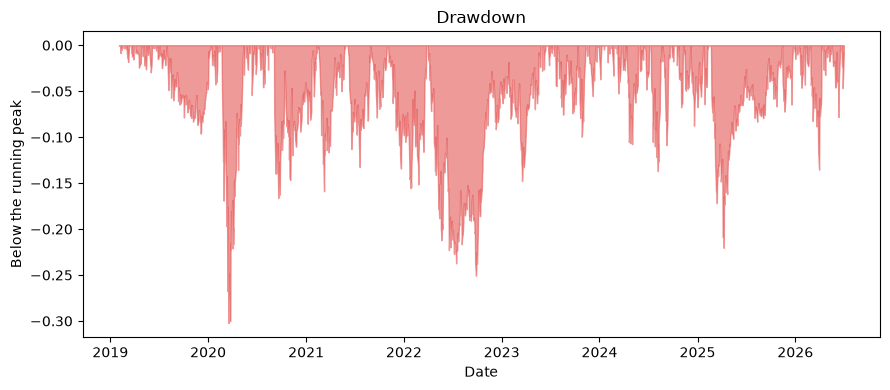

In [9]:
underwater = strategy.underwater().to_pandas()
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(underwater["ts"], underwater["drawdown"], 0, alpha=0.6, color="#e45756")
ax.set_title("Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Below the running peak")
fig.tight_layout()

## 5. ローリング統計

ローリングの窓は、1つの数字では答えられない問いに答えます。最初から最後まで同じ戦略だったのか。
`rolling_beta` はスライド窓の共分散集約を避け、エンジンの `ts_cov` を使います。DataFusion は
組み込みの共分散から値を取り除けないからです。

In [10]:
window = 126
rolling = (
    strategy.rolling_sharpe(window).to_pandas()
    .merge(strategy.rolling_volatility(window).to_pandas(), on="ts")
    .merge(strategy.rolling_beta(benchmark, window).to_pandas(), on="ts")
    .dropna()
)
print(f"{len(rolling):,} complete {window}-day windows")
rolling.tail(3).round(3)

1,737 complete 126-day windows


/tmp/ipykernel_99373/2029973743.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  rolling.tail(3).round(3)


,ts,rolling_sharpe,rolling_volatility,rolling_beta
1859,2026-06-26 20:00:00+00:00,1.336,0.285,1.723
1860,2026-06-29 20:00:00+00:00,1.521,0.288,1.744
1861,2026-06-30 20:00:00+00:00,1.587,0.288,1.733


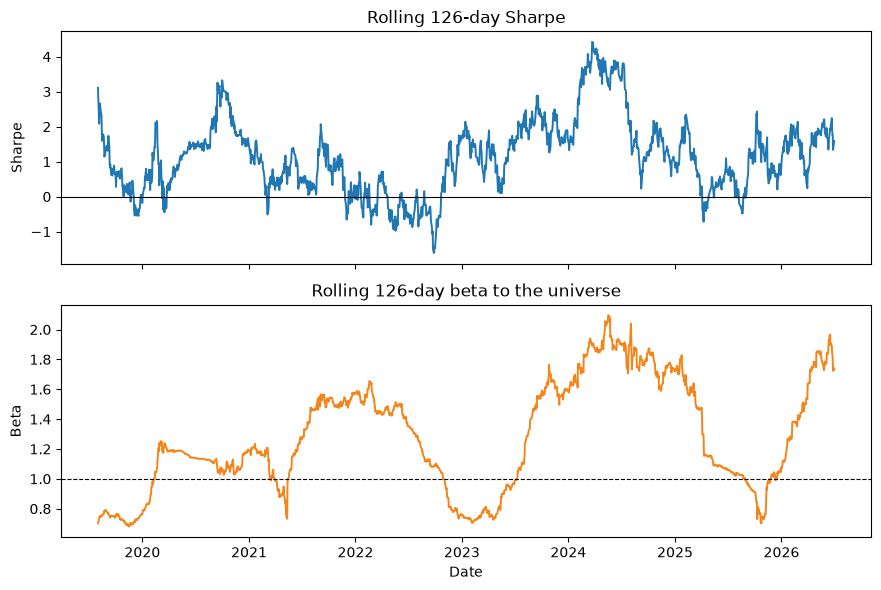

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(rolling["ts"], rolling["rolling_sharpe"], linewidth=1.4)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title(f"Rolling {window}-day Sharpe")
axes[0].set_ylabel("Sharpe")
axes[1].plot(rolling["ts"], rolling["rolling_beta"], linewidth=1.4, color="#f58518")
axes[1].axhline(1, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title(f"Rolling {window}-day beta to the universe")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Beta")
fig.tight_layout()

## 6. ティアシート

`quant.tearsheet` は標準のページを描きます。見出しの統計量、累積リターン、ドローダウン、
ローリング・シャープ、ドローダウン表、そして来歴のヘッダーです。チャートは外部リクエストの
ないインライン SVG です。*読む* ためにプロットのライブラリをインストールしなければならない
レポートは、レポートではないからです。

In [12]:
html = quant.tearsheet(
    strategy,
    path="data/cache/momentum-tearsheet.html",
    benchmark=benchmark,
    title="12-1 momentum, top three",
    rolling_window=window,
    top_drawdowns=5,
)
print(f"wrote {len(html):,} bytes of self-contained HTML")
payload = quant.report_payload(strategy, benchmark=benchmark)
print(f"headline rows {len(payload['headline'])}, charts {len(payload['charts'])}")
print([chart["id"] for chart in payload["charts"]])

wrote 491,385 bytes of self-contained HTML
headline rows 12, charts 3
['equity', 'underwater', 'rolling-sharpe']


## 7. バックテストの実行からティアシートへ

実行はフォークに `bt_equity` を書きます。これはリターン系列ではありません。*水準* の系列です。
`quant.from_levels` がその橋渡しで、最初のバーをゼロリターンと呼ばずに落とします。どの
カーブの先頭にも偽のフラットなバーを置くのは、複利で効いてくる嘘だからです。

In [13]:
frame = daily.to_pandas()
frame = frame[
    (frame["symbol"].isin(["AAPL", "MSFT", "JPM"]))
    & (frame["ts"] >= pd.Timestamp("2024-01-01", tz="UTC"))
]
market = cu.make_equity_market(pa.Table.from_pandas(frame, preserve_index=False))
run_db = h5i_db.Database(cu.fresh_db("06_tearsheet_run"), create=True)
for name in ("instruments", "book_deltas", "trades"):
    table = market[name]
    run_db.create_table(name, table.schema, time_column="ts_init")
    run_db.append(name, table)
run_db.snapshot("tape-v1", tables=["instruments", "book_deltas", "trades"])

book = market["book_deltas"].to_pandas()
book["session"] = book["ts_init"].dt.floor("s").dt.tz_localize("UTC")
first = book.groupby("instrument_id")["ts_init"].min()
signals = backtest.signal_table(
    [
        {
            "ts": stamp + dt.timedelta(microseconds=1),
            "instrument_id": symbol,
            "side": "buy",
            "quantity": 100.0,
            "tag": "buy-and-hold",
        }
        for symbol, stamp in first.items()
    ]
)
backtest.create_signal_table(run_db)
run_db.append("signals", signals)
report = backtest.run(
    run_db,
    "buy-and-hold",
    starting_cash=200_000.0,
    signals="signals",
    snapshot="tape-v1",
    fee_kind="proportional",
    fee_rate=0.0005,
    equity_interval_nanos=86_400_000_000_000,
)
fork = run_db.fork(report["fork"])
run_series = quant.from_levels(fork, "bt_equity", level="equity", annualization=quant.DAILY)
run_stats = run_series.stats()
print(f"{report['fills']} fills, {len(fork.read('bt_equity')):,} equity samples")
pd.Series(run_stats).to_frame("buy and hold").round(4)

3 fills, 626 equity samples


,buy and hold
n_periods,625
period_start,2024-01-03 20:00:00
period_end,2026-06-30 20:00:00.000002
cumulative_return,0.130287
annual_return,0.05062
annual_volatility,0.067005
sharpe_ratio,0.770518
sortino_ratio,1.06856
downside_risk,0.048316
max_drawdown,-0.097191


## 8. 引用できる数字

`quant.verify` は計算を再実行し、両方を確認します。来歴のダイジェストと、計算し直した値です。
ピン留めされていない系列は、合格せず *検証不能* として報告されます。「最新」を2回読んで
一致したことが証明するのは、その数秒のあいだ何も変わらなかったことだけだからです。

In [14]:
verified = quant.verify(strategy, rerun=lambda: quant.returns(
    db, "strategy_returns", snapshot="returns-v1", annualization=quant.DAILY))
print(f"verified {verified['verified']}, pinned {verified['pinned']}")

unpinned = quant.returns(db, "strategy_returns", annualization=quant.DAILY)
try:
    quant.verify(unpinned)
except quant.VerificationError as error:
    print(f"\nunpinned refused: {str(error)[:110]}...")
relaxed = quant.verify(unpinned, strict=False)
print(f"non-strict report: verified={relaxed['verified']} reason={relaxed['reason']!r}")

verified True, pinned True

unpinned refused: cannot verify an unpinned computation: it read the latest version, which may already have moved. Re-run it aga...
non-strict report: verified=False reason='unpinned computation'


この拒否に意味を与えているのが来歴のヘッダーです。ピン、パラメータ、SQL を記録するので、
同じピンから作り直したティアシートは、似た数字ではありません。同じ数字を再現します。

In [15]:
provenance = strategy.provenance
print(f"kind        {provenance.kind}")
print(f"digest      {provenance.digest}")
print(f"pin         {provenance.pin}")
print(f"parameters  {provenance.parameters}")
print(f"warnings    {list(provenance.warnings()) or 'none'}")

kind        return_series
digest      bd224785e4cfe47f765ffc2d6bcc094e1881935ee7be4e2565198bd2468f82ca
pin         Pin(version=None, as_of=None, snapshot='returns-v1', event_time_cutoff=None)
parameters  {'annualization': 252, 'deterministic': True}
warnings    none


## まとめ

- リターン系列はすべてのパフォーマンス統計の入力です。テーブルとして保存すれば、2つの
  レポートがそれについて食い違うことはありません。
- `ReturnSeries.stats()` は `empyrical` と一致し、ベンチマークを渡すと、重なる日についてだけ
  アルファとベータが加わります。
- ドローダウンは継続期間を持つ出来事であって、最悪の1つの数字ではありません。
- `from_levels` は実行の `bt_equity` を同じオブジェクトに変えるので、バックテストとリサーチの
  系列を同じコードで分析できます。
- `quant.tearsheet` は来歴のヘッダー付きの自己完結したページを描きます。
- `quant.verify` はピン留めされていない計算の検証を拒みます。その拒否こそが機能です。

In [16]:
fork.close()
run_db.close()
db.close()